In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.metrics import roc_auc_score

df = pd.read_csv("../data/cleaned_loan_data.csv")

X = df.drop(columns=['SeriousDlqin2yrs'])
y = df['SeriousDlqin2yrs']

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print(X_train.shape, X_val.shape)

(119999, 15) (30000, 15)



Noise level: 0%
  RandomForest: AUC=0.8678
  AdaBoost: AUC=0.8611
  GradientBoosting: AUC=0.8695

Noise level: 5%
  RandomForest: AUC=0.8679
  AdaBoost: AUC=0.8538
  GradientBoosting: AUC=0.8661

Noise level: 10%
  RandomForest: AUC=0.8670
  AdaBoost: AUC=0.8522
  GradientBoosting: AUC=0.8627

Noise level: 15%
  RandomForest: AUC=0.8633
  AdaBoost: AUC=0.8497
  GradientBoosting: AUC=0.8551

Noise level: 20%
  RandomForest: AUC=0.8629
  AdaBoost: AUC=0.8493
  GradientBoosting: AUC=0.8498

Noise level: 25%
  RandomForest: AUC=0.8605
  AdaBoost: AUC=0.8360
  GradientBoosting: AUC=0.8422


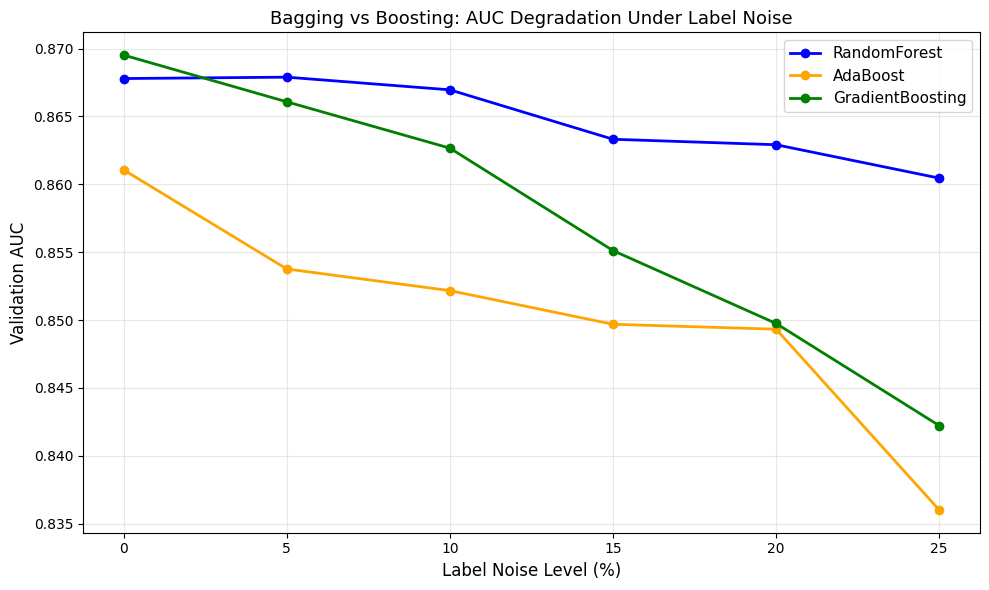

Plot saved.


In [3]:
noise_levels = [0.0, 0.05, 0.10, 0.15, 0.20, 0.25]

# Store results: {model_name: [auc_at_each_noise_level]}
noise_results = {
    'RandomForest': [],
    'AdaBoost': [],
    'GradientBoosting': []
}

# Use the best hyperparameters we found in Phase 4
models = {
    'RandomForest': RandomForestClassifier(max_depth=10, min_samples_leaf=20, random_state=42),
    'AdaBoost': AdaBoostClassifier(learning_rate=0.5, n_estimators=200, random_state=42),
    'GradientBoosting': GradientBoostingClassifier(learning_rate=0.1, max_depth=5, random_state=42)
}

for noise in noise_levels:
    print(f"\nNoise level: {int(noise*100)}%")
    
    # Copy clean training labels
    y_train_noisy = y_train.copy().values
    
    # Randomly select indices to flip
    n_flip = int(noise * len(y_train_noisy))
    flip_indices = np.random.RandomState(42).choice(len(y_train_noisy), n_flip, replace=False)
    
    # Flip labels: 0→1, 1→0
    y_train_noisy[flip_indices] = 1 - y_train_noisy[flip_indices]
    
    for name, model in models.items():
        model.fit(X_train, y_train_noisy)
        # Always evaluate on CLEAN validation set
        auc = roc_auc_score(y_val, model.predict_proba(X_val)[:, 1])
        noise_results[name].append(auc)
        print(f"  {name}: AUC={auc:.4f}")

# Plot degradation curves
plt.figure(figsize=(10, 6))
colors = {'RandomForest': 'blue', 'AdaBoost': 'orange', 'GradientBoosting': 'green'}
for name, aucs in noise_results.items():
    plt.plot([n*100 for n in noise_levels], aucs, 
             marker='o', label=name, color=colors[name], linewidth=2)

plt.xlabel('Label Noise Level (%)', fontsize=12)
plt.ylabel('Validation AUC', fontsize=12)
plt.title('Bagging vs Boosting: AUC Degradation Under Label Noise', fontsize=13)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../data/noise_robustness.png', dpi=150)
plt.show()
print("Plot saved.")

n_estimators=10
  RF: 0.8645
  AdaBoost: 0.8486
  GBM: 0.8601
n_estimators=25
  RF: 0.8661
  AdaBoost: 0.8546
  GBM: 0.8663
n_estimators=50
  RF: 0.8667
  AdaBoost: 0.8553
  GBM: 0.8687
n_estimators=75
  RF: 0.8674
  AdaBoost: 0.8572
  GBM: 0.8693
n_estimators=100
  RF: 0.8678
  AdaBoost: 0.8576
  GBM: 0.8695
n_estimators=150
  RF: 0.8680
  AdaBoost: 0.8597
  GBM: 0.8695
n_estimators=200
  RF: 0.8680
  AdaBoost: 0.8611
  GBM: 0.8693
n_estimators=300
  RF: 0.8682
  AdaBoost: 0.8626
  GBM: 0.8679
n_estimators=400
  RF: 0.8682
  AdaBoost: 0.8640
  GBM: 0.8666
n_estimators=500
  RF: 0.8683
  AdaBoost: 0.8655
  GBM: 0.8655


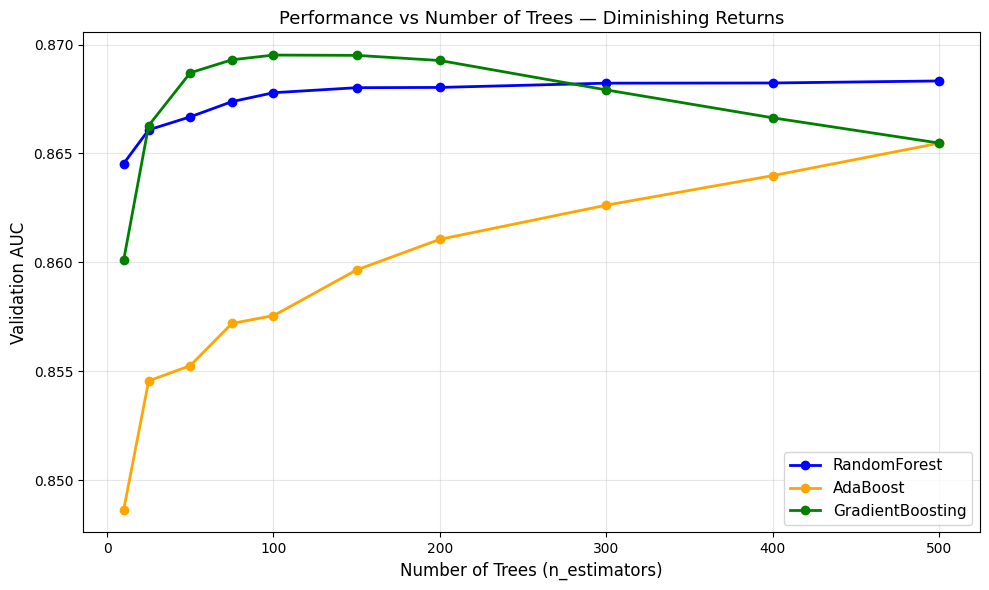

Plot saved.


In [4]:
tree_counts = [10, 25, 50, 75, 100, 150, 200, 300, 400, 500]

tree_results = {
    'RandomForest': [],
    'AdaBoost': [],
    'GradientBoosting': []
}

for n in tree_counts:
    print(f"n_estimators={n}")

    # Random Forest — best hyperparams from Phase 4
    rf = RandomForestClassifier(
        n_estimators=n, max_depth=10, 
        min_samples_leaf=20, random_state=42
    )
    rf.fit(X_train, y_train)
    auc = roc_auc_score(y_val, rf.predict_proba(X_val)[:, 1])
    tree_results['RandomForest'].append(auc)
    print(f"  RF: {auc:.4f}")

    # AdaBoost — best hyperparams from Phase 4
    ada = AdaBoostClassifier(
        n_estimators=n, learning_rate=0.5, random_state=42
    )
    ada.fit(X_train, y_train)
    auc = roc_auc_score(y_val, ada.predict_proba(X_val)[:, 1])
    tree_results['AdaBoost'].append(auc)
    print(f"  AdaBoost: {auc:.4f}")

    # GradientBoosting — best hyperparams from Phase 4
    gbm = GradientBoostingClassifier(
        n_estimators=n, learning_rate=0.1, 
        max_depth=5, random_state=42
    )
    gbm.fit(X_train, y_train)
    auc = roc_auc_score(y_val, gbm.predict_proba(X_val)[:, 1])
    tree_results['GradientBoosting'].append(auc)
    print(f"  GBM: {auc:.4f}")

# Plot
plt.figure(figsize=(10, 6))
colors = {'RandomForest': 'blue', 'AdaBoost': 'orange', 'GradientBoosting': 'green'}

for name, aucs in tree_results.items():
    plt.plot(tree_counts, aucs, marker='o', 
             label=name, color=colors[name], linewidth=2)

plt.xlabel('Number of Trees (n_estimators)', fontsize=12)
plt.ylabel('Validation AUC', fontsize=12)
plt.title('Performance vs Number of Trees — Diminishing Returns', fontsize=13)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../data/diminishing_returns.png', dpi=150)
plt.show()
print("Plot saved.")